In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
%matplotlib widget

In [2]:
plt.style.use("fivethirtyeight")

In [3]:
axes_settings = {"top":False, "right":False}
plt.rc("axes.spines", **axes_settings)

In [4]:
path = "./total-production.csv"

In [5]:
coffee_production = pd.read_csv(path, encoding="utf-8", sep=",")

# Meshgrid - Single Figure Report on Brazil's Place in Global Coffee Market

* Create a Meshgrid Layout to combine our findings from our first project into a single report. 
* We want the two donut charts representing Brazil's production share in 1990 and 2018 in the top third of the figure. 
* The stackplot comparing Brazil to the rest of the world in the center of the figure. 
* In the bottom third a bar chart showing the total production of our top 5 countries, as well as a bar for other. Also include a pie chart showing the composition of the same data plotted in the bar chart. 
* Look up the country colors for our top 5 countries and color them accordingly. For 'other' category, color these grey.
* Consider setting rcParams to turn top and right borders off.
* Save the report out as an image.

In [6]:
coffee_production.head()

,total_production,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Angola,50.3450,79.3310,77.5200,32.6080,76.802,62.1090,70.925,64.330,85.3440,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
1,Bolivia (Plurinational State of),122.7770,103.5360,120.2350,50.8230,116.944,142.4850,124.579,140.719,137.9850,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687
2,Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,...,43976.8120,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836
3,Burundi,487.3930,667.1990,620.2380,393.3540,664.143,433.9800,400.969,249.785,491.9920,...,111.6130,352.9776,204.1328,405.9615,163.2177,247.5500,274.1017,248.7933,202.1079,178.4206
4,Ecuador,1503.8150,2123.8240,1185.4800,2069.0070,2375.766,1888.2330,1992.914,1190.663,1205.9680,...,813.2849,853.9798,825.4144,828.1024,665.5450,644.0112,644.4926,644.8845,623.5744,601.0001


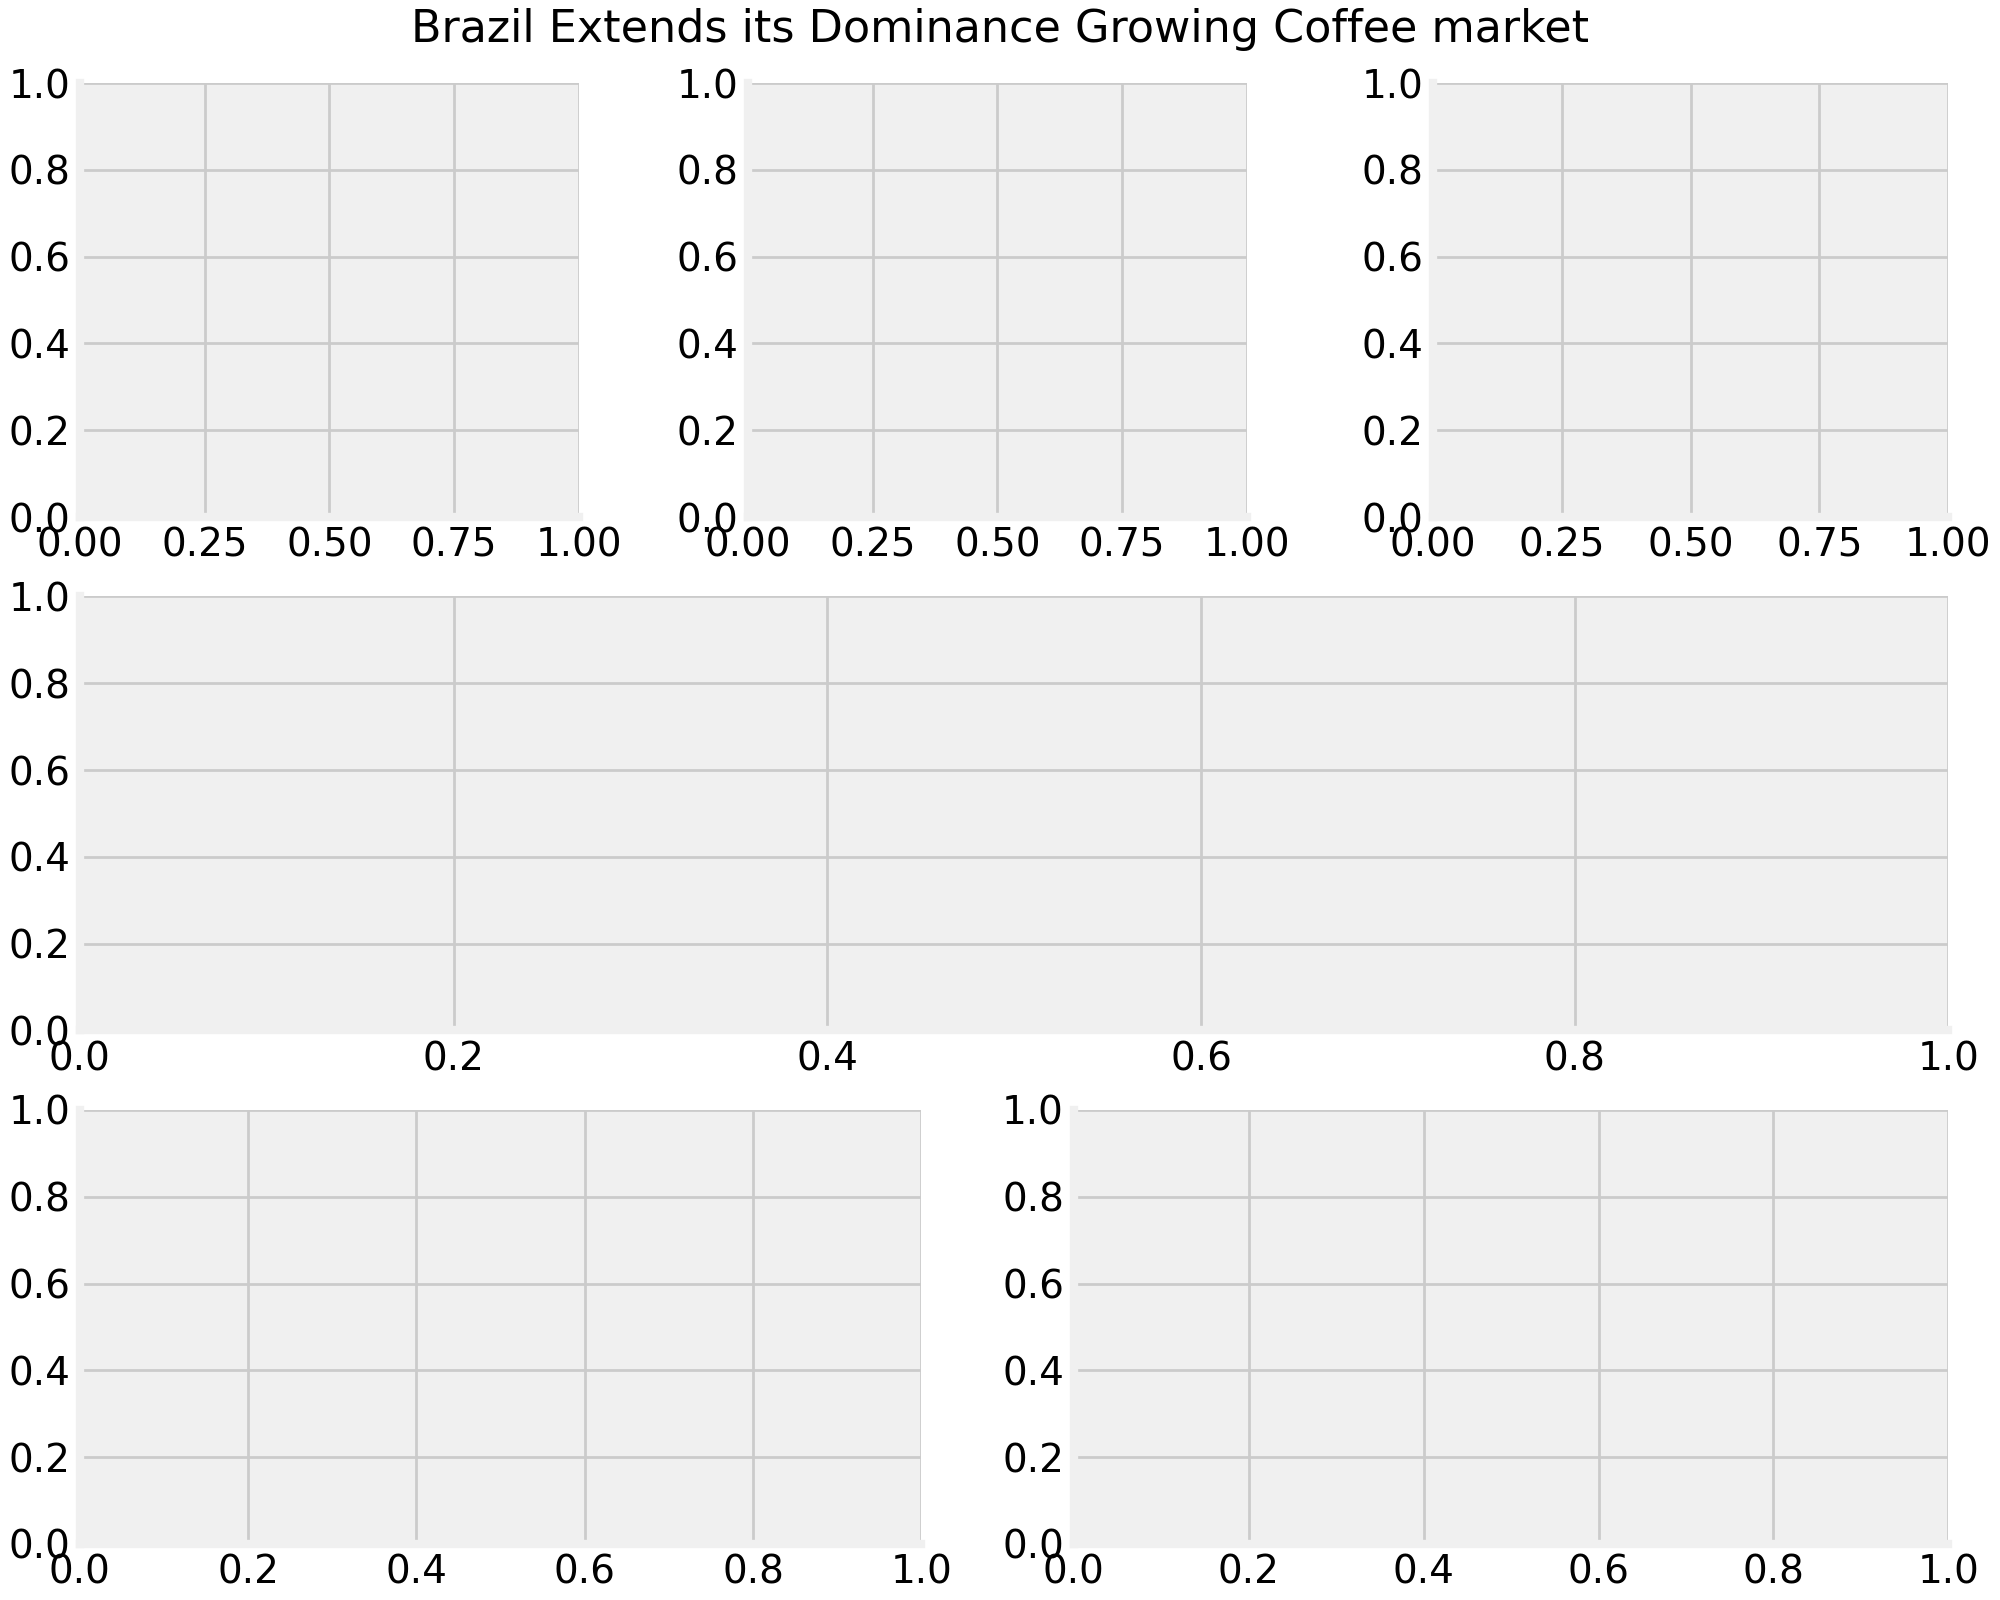

In [7]:
fig = plt.figure(
	num="Analysis_coffee",
	dpi=200,
	figsize=(10,8),
	facecolor="white",
	layout="constrained"
)
fig.suptitle("Brazil Extends its Dominance Growing Coffee market", fontsize=16)

gs = GridSpec(nrows=3, ncols=6, figure=fig)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:])
ax4 = fig.add_subplot(gs[1, :])
ax5 = fig.add_subplot(gs[2, :3])
ax6 = fig.add_subplot(gs[2, 3:])

In [8]:
ax1.text(
	x=0.2,
	y=0.5,
	ha="left",
	va="top",
	s="See the Charts",
	zorder=3,

	color="black",
	family="serif",
	fontsize="15",
	fontweight="normal",
	fontstyle="italic",

	bbox={
		"boxstyle":"square",
		"linestyle":"-.",
		"edgecolor":"r",
		"facecolor":"grey",
		"linewidth":2
	},
	snap=True,

	alpha=0.8,
	rotation=0
)
ax1.set_axis_off();
# display(fig)

In [9]:
coffee_production = (coffee_production
	.rename(columns={"total_production":"Country"})
	.set_index("Country")
	.assign(TotalProduction=lambda x: x.sum(axis=1))
	.sort_values(by="TotalProduction", ascending=False)
		   )


In [10]:
coffee_production_2 = (coffee_production
	.drop(columns="TotalProduction")
	.T
	.reset_index()
	.rename(columns=({"index":"Years"}))
	.astype({"Years":"datetime64[ns]"})
	.set_index("Years")
	   )

In [11]:
brazil_vs_others = pd.concat([coffee_production_2.iloc[:, 0],
							pd.DataFrame(coffee_production_2.iloc[:,1:].sum(axis=1), columns=["OTH"])], axis=1
							)

brazil_vs_others.head()

,Brazil,OTH
Years,,
1990-01-01,27285.6286,65944.431
1991-01-01,27293.4934,73973.191
1992-01-01,34603.3542,63922.545
1993-01-01,28166.9786,63597.643
1994-01-01,28192.0470,65121.147


In [12]:
wedges, texts, autotexts = ax2.pie(
	brazil_vs_others.iloc[0],
	labels=["Brazil", "OTH"],
	labeldistance=1.2,
	autopct="%1.0f%%",
	pctdistance=0,
	textprops={"color":"black", "fontsize":"16"},

	colors=("b", "white"),
	wedgeprops={"width":0.30},

	startangle=90,
	counterclock=False,
)

for i, item in enumerate(autotexts):
    if i != 0: 
        item.set_text("")
for i, item in enumerate(texts):
    item.set_text("") 

wedges, texts, autotexts = ax3.pie(
	brazil_vs_others.iloc[-1],
	labels=["Brazil", "OTH"],
	labeldistance=1.2,
	autopct="%1.0f%%",
	pctdistance=0,
	textprops={"color":"black", "fontsize":"16"},

	colors=("b", "white"),
	wedgeprops={"width":0.30},

	startangle=90,
	counterclock=False,
)

ax2.set_title("Brazil % Global Production - 1990", fontsize=12)
ax3.set_title("Brazil % Global Production - 2018", fontsize=12)

for i, item in enumerate(autotexts):
    if i != 0: 
        item.set_text("")
for i, item in enumerate(texts):
    item.set_text("") 
# display(fig)
;

''

In [13]:
ax4.stackplot(
	brazil_vs_others.index,
	brazil_vs_others["Brazil"] / 1000,
	brazil_vs_others["OTH"] / 1000,
	
	colors=("r", "b"),
	# edgecolor="0.0",
	# linewidth=1,

	# hatch="x",
	baseline="zero",
	zorder=3,

	alpha=0.7,
	labels=["Brazil", "Others"]
)

ax4.legend(frameon=False, fontsize=10)
ax4.set_title("Brazil's Share of Market", y=1.02, fontsize=12)
ax4.set_xlabel(brazil_vs_others.index.name, fontsize=8)
ax4.set_ylabel("Total Production (in thousands)", fontsize=8)
ax4.tick_params(labelsize=8)

# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# display(fig);
;

''

In [14]:
coffee_production_top5_2018 = pd.concat(
	[
		coffee_production.iloc[:6, -1],
		pd.DataFrame(
			[coffee_production.iloc[6:,-1].sum(axis=0)],
			columns=["TotalProduction"],
			index=["OTH"]
		)
	]
	, axis=0)

coffee_production_top5_2018 

,TotalProduction
Brazil,1.190966e+06
Viet Nam,4.395410e+05
Colombia,3.458714e+05
Indonesia,2.451168e+05
Ethiopia,1.415429e+05
India,1.320257e+05
OTH,1.093366e+06


In [15]:
ax5.barh(
	y=coffee_production_top5_2018.index[::-1],
	width=coffee_production_top5_2018["TotalProduction"][::-1] / 1000000,
	height=0.8,
	left=0,
	align="center",
	zorder=3,

	color=["#009739", "#DA251D", "#FCD116", "#FF0000", "#013971", "#FF9933", "grey"][::-1],
)

ax5.set_title("Top Coffee Producing Nations", fontsize=12)
ax5.set_xlabel("Production in millions (60 kg bags)", fontsize=8)
ax5.tick_params(labelsize=8)
# display(fig)
;

''

In [16]:
ax6.pie(
	coffee_production_top5_2018.iloc[:,0],
	labels=coffee_production_top5_2018.index,
	labeldistance=1.2,
	autopct="%1.0f%%",
	pctdistance=0.8,
	textprops={"color":"black", "fontsize":"7"},

	explode=(0.15, 0, 0, 0, 0, 0, 0),
	# wedgeprops={"width":0.35},

	startangle=90,
	counterclock=False

)

ax6.set_title("Share of Global Coffee Production", y=1.02, fontsize=12)
# display(fig);
;

''

In [17]:
fig.savefig("part2", dpi=500, bbox_inches='tight')

# Subplots

* Read in `prices-paid-to-growers.csv` and create a subplot grid of histograms showing the distribution of prices paid to the countries Brazil, Colombia, Ethiopia, and one for all other nations.

In [18]:
prices_paid_to_growers = pd.read_csv("./prices-paid-to-growers.csv").T.drop(9, axis=1)

prices_paid_to_growers.columns= prices_paid_to_growers.iloc[0]

prices_paid_to_growers.drop("prices_paid_to_growers", inplace=True)

prices_paid_to_growers["Other Nations"] =  prices_paid_to_growers.drop(["Colombia", "Brazil", "Ethiopia"], axis=1).mean(axis=1)

In [19]:
prices_paid_to_growers.head()

prices_paid_to_growers,Colombia,Dominican Republic,El Salvador,Guatemala,Honduras,India,Uganda,Brazil,Ethiopia,India,Togo,Uganda,Other Nations
1990,1.534724,1.458168,1.116194,1.204956,1.11147,1.473558,0.337598,1.199223,1.348565,0.978921,0.645267,0.166486,0.943624
1991,1.48179,1.382845,0.983322,1.270086,1.238947,1.358371,0.654322,0.97115,1.505322,0.897289,0.632307,0.26143,0.964325
1992,1.204656,1.027841,0.682322,0.888099,0.886057,1.191159,0.441397,0.997768,1.351128,0.877945,0.658494,0.197653,0.761219
1993,1.106477,1.172704,0.780397,0.914552,0.828746,1.278669,0.552298,1.167263,1.362442,0.975912,0.499857,0.259737,0.806986
1994,1.898327,2.478234,2.191177,1.662711,1.800576,1.73081,1.666651,2.52911,2.418234,1.246437,0.573784,0.919709,1.585565


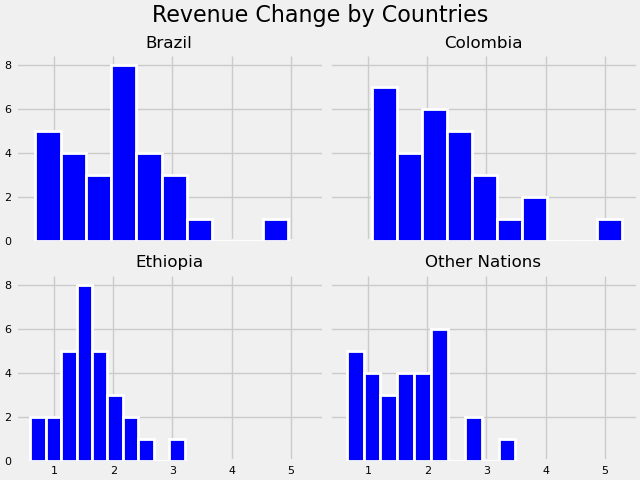

In [20]:
fig2, axes = plt.subplots(
	num="Analysis coffee 2",
	layout="constrained",
	ncols=2,
	nrows=2,
	sharex=True,
	sharey=True
)

fig2.suptitle("Revenue Change by Countries", fontsize=16)

countries = np.array(["Brazil", "Colombia", "Ethiopia", "Other Nations"])
countries = countries.reshape(2, 2)

for i in range(2):
	for j in range(2):
		# if (i, j) == (1, 2):
		# 	ax[i, j].set_axis_off()
		# 	continue
		if i == 0:
			axes[i, j].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
		if j != 0:
			axes[i, j].tick_params(axis='y', which='both', bottom=False, labelbottom=False)
		axes[i, j].hist(
			x=prices_paid_to_growers.loc[:, countries[i, j]],
			bins=10,
			range=None,
			rwidth=1,
			bottom=0,
			align="mid",
			zorder=3,
		
			color="b",
			edgecolor="white",
			linewidth=2,
		
			histtype="bar",
			orientation="vertical",
			stacked=False,
		
		
			density=False,
			log=False,
			cumulative=False,
		
			# label=countries[i, j],
			alpha=1
		)
		axes[i, j].set_title(countries[i, j], fontsize=12)
		axes[i, j].tick_params(labelsize=8);